In [189]:
#step 1: import the library
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import pandas as pd
tf.__version__
keras.__version__

'3.10.0'

In [246]:
#step 2: import a toy dataset
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()


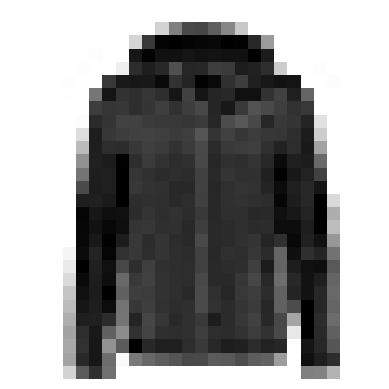

In [247]:
#step 3: normalize and scale the toy dataset
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

class_names [y_train [0]]
plt.imshow(X_train[0], cmap="binary")
plt.axis ('off')
plt.show()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_21 (LeakyReLU)           │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_22               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_22 (LeakyReLU)           │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_23               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_23 (LeakyReLU)           │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


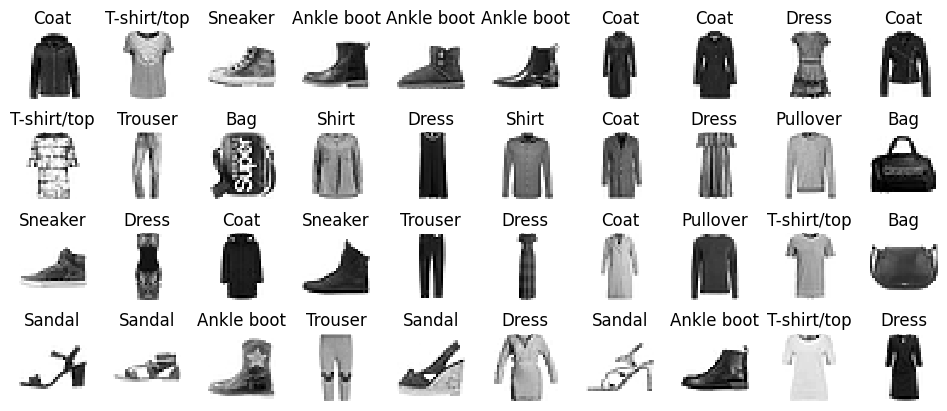

In [248]:
#step 4: OPTIMIZED MODEL ARCHITECTURE (Updated for current Keras version)
model = keras.models.Sequential([
    # Use Input layer instead of input_shape in Flatten
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    
    # First dense block
    keras.layers.Dense(512, 
        kernel_initializer='he_normal',
        kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(negative_slope=0.1),  # Changed from alpha to negative_slope
    keras.layers.Dropout(0.3),
    
    # Second dense block
    keras.layers.Dense(256, 
        kernel_initializer='he_normal',
        kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(negative_slope=0.1),  # Changed from alpha to negative_slope
    keras.layers.Dropout(0.3),
    
    # Third dense block
    keras.layers.Dense(128, 
        kernel_initializer='he_normal',
        kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(negative_slope=0.1),  # Changed from alpha to negative_slope
    keras.layers.Dropout(0.2),
    
    # Output layer
    keras.layers.Dense(10, activation="softmax")
])

#print and describe model shape
model.summary()

keras.utils.plot_model(model, "my_fashion_mnist_model.png", show_shapes=True)

#more example images
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range (n_rows) :
    for col in range (n_cols) :
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis ('off')
        plt.title(class_names[y_train[index]], fontsize=12)
plt.subplots_adjust (wspace=0.2, hspace=0.5)
plt.show ()

In [249]:
#step 5: OPTIMIZED COMPILATION
# CHANGED OPTIMIZATION: Using Adam instead of SGD
optimizer = keras.optimizers.Adam(
    learning_rate=0.00003,
    beta_1=0.9,
    beta_2=0.999
)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,  # CHANGED OPTIMIZER
    metrics=["accuracy"]
)

In [256]:
#step 6: ENHANCED TRAINING
# Added callbacks for better training control
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=10,
        min_lr=0.000001,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "best_fashion_mnist_model.keras",
        save_best_only=True,
        monitor='val_loss'
    )
]

# Fit with callbacks and adjusted parameters
history = model.fit(
    X_train, y_train, 
    epochs=50,  # Increased epochs (early stopping will prevent overfitting)
    batch_size=32,  # Added batch size specification
    validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9590 - loss: 0.1810 - val_accuracy: 0.9134 - val_loss: 0.3450 - learning_rate: 1.0000e-06
Epoch 2/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9582 - loss: 0.1813 - val_accuracy: 0.9138 - val_loss: 0.3438 - learning_rate: 1.0000e-06
Epoch 3/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9590 - loss: 0.1827 - val_accuracy: 0.9118 - val_loss: 0.3445 - learning_rate: 1.0000e-06
Epoch 4/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9599 - loss: 0.1802 - val_accuracy: 0.9130 - val_loss: 0.3442 - learning_rate: 1.0000e-06
Epoch 5/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9586 - loss: 0.1804 - val_accuracy: 0.9146 - val_loss: 0.3432 - learning_rate: 1.0000e-06
Epoch 6/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9611 - loss: 0.1772 - val_accuracy: 0.9144 - val_loss: 0.3455 - learning_rate: 1.0000e-06
Epoch 7/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 

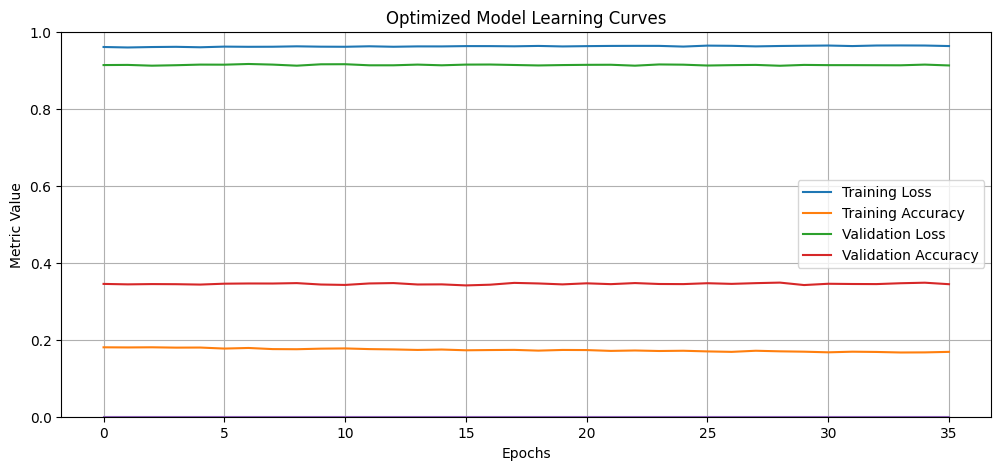

In [257]:
#step 8: plot learning curves
pd.DataFrame(history.history).plot(figsize=(12, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title("Optimized Model Learning Curves")
plt.xlabel("Epochs")
plt.ylabel("Metric Value")
plt.legend(["Training Loss", "Training Accuracy", "Validation Loss", "Validation Accuracy"])
plt.savefig("optimized_keras_learning_curves.png")
plt.show()

In [215]:
#step 9: evaluate the trained model on testing data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0969 - loss: 4.1163

Final Test Accuracy: 0.1000
Final Test Loss: 4.0980
